# E1 — Convention from use (the Lewis signaling game)

*A working demonstration of Beetle-Box experiment **E1**. Full write-up:
[`docs/e1_signaling.md`](../docs/e1_signaling.md). This notebook runs live on CPU
in a few seconds and doubles as a smoke test.*

**The thin question.** Wittgenstein's *meaning is use* says a word's meaning lives
in the public practice of using it, not in a private object it names. A **Lewis
signaling game** is the barest arena for that claim: a sender and a receiver must
coordinate on signals that begin **meaningless**, and whatever meaning the signals
acquire is *constituted by* the coordinated practice.

E1 asks only: **can meaning-as-use happen at all, from scratch, between agents
given no prior conventions?** It says nothing about "understanding" or inner
states — those belong to E3 (§293) and E5 (grounding). E1 is the baseline every
later experiment perturbs.

We will see four things:
1. **Emergence** — a convention forms from feedback-driven use.
2. **Ablation** — with no success signal, coordination stays at chance (the game,
   not a leak, is doing the work).
3. **Turnover** — a convention survives its founders.
4. **Compositional structure** — structured referents give rise to structured codes.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from beetlebox.config import RunConfig
from beetlebox.harness import RunManager
from beetlebox.channels import SymbolChannel
from beetlebox.envs import SignalingEnv
from beetlebox.analysis import metrics
from beetlebox.runlog import RunLogger, iter_events

warnings.filterwarnings("ignore")

# Okabe-Ito colorblind-safe categorical palette, used in fixed order (never cycled).
OKABE = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "green":  "#009E73",
    "vermil": "#D55E00",
    "purple": "#CC79A7",
    "sky":    "#56B4E9",
}

# Clean, recessive chart style.
plt.rcParams.update({
    "figure.figsize": (7.5, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 12, "axes.titleweight": "bold", "font.size": 10,
    "lines.linewidth": 2.0,
})
print("ready")

ready


In [2]:
import tempfile

def run_condition(cfg: RunConfig, tag: str):
    """Run one E1 condition, returning (eval_steps, eval_accs, summary).

    Uses a RunLogger to a scratch dir so we can read back the per-eval learning
    curve from the structured event stream (the same logs the CLI writes).
    """
    tmp = tempfile.mkdtemp(prefix=f"e1_{tag}_")
    with RunLogger(tmp) as logger:
        summary = RunManager(cfg, logger=logger).run()
    steps, accs = [], []
    for ev in iter_events(tmp):
        if ev.get("event") == "eval":
            steps.append(ev["step"]); accs.append(ev["accuracy"])
    return np.array(steps), np.array(accs), summary

print("helper defined")

helper defined


## 1. Emergence — a convention forms from use

The sender sees a referent and emits symbols from an **invented** vocabulary (no
English); the receiver reconstructs the referent from the message alone. Success
is rewarded. Nothing is labelled in advance — the *referent → message → referent*
mapping must be invented jointly. Chance is `1/K`.

In [3]:
cfg = RunConfig(seed=0)
cfg.experiment.num_steps = 3000
cfg.experiment.eval_every = 100
steps, accs, summary = run_condition(cfg, "default")
chance = summary["chance"]
print(f"final accuracy = {summary['final_accuracy']:.3f}   (chance = {chance:.3f})")

final accuracy = 1.000   (chance = 0.125)


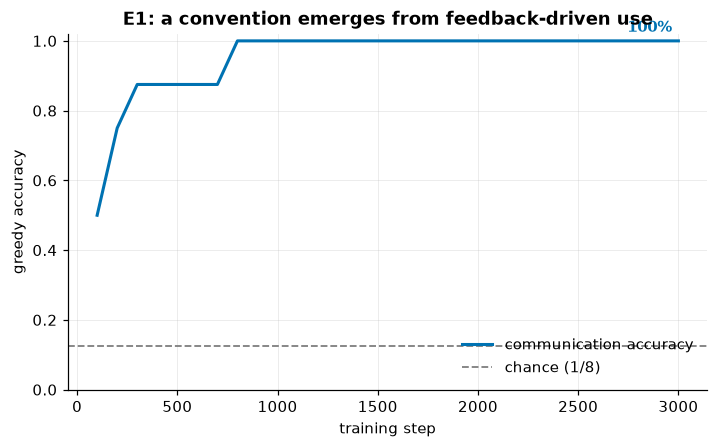

In [4]:
fig, ax = plt.subplots()
ax.plot(steps, accs, color=OKABE["blue"], label="communication accuracy")
ax.axhline(chance, color="0.5", ls="--", lw=1.2, label=f"chance (1/{summary['num_classes']})")
ax.set_xlabel("training step"); ax.set_ylabel("greedy accuracy")
ax.set_ylim(0, 1.02); ax.set_title("E1: a convention emerges from feedback-driven use")
ax.annotate(f"{accs[-1]:.0%}", xy=(steps[-1], accs[-1]),
            xytext=(-4, 6), textcoords="offset points", color=OKABE["blue"],
            fontweight="bold", ha="right")
ax.legend(frameon=False, loc="lower right"); plt.show()

Accuracy climbs from chance to near-perfect: a shared convention has emerged with
no meanings supplied in advance. We score it against the **frozen**
pre-registration (`prereg/e1_signaling.yaml`) — the criteria were fixed before the
run, never tuned to it.

In [5]:
from beetlebox.analysis.metrics import convention_stability
# Convention stability: agreement of the greedy referent->message map over the
# final evals. 1.0 means the convention froze rather than kept wandering.
tmp = tempfile.mkdtemp(prefix="e1_stab_")
with RunLogger(tmp) as logger:
    RunManager(cfg, logger=logger).run()
evals = [e for e in iter_events(tmp) if e.get("event") == "eval"]
stability = convention_stability(evals, window=5)
print(f"convention stability (last 5 evals) = {stability:.3f}")
print(f"emergence: {summary['final_accuracy']:.3f} >= 0.90 and "
      f">= 3x chance ({3*chance:.3f})? "
      f"{summary['final_accuracy'] >= 0.90 and summary['final_accuracy'] >= 3*chance}")

convention stability (last 5 evals) = 1.000
emergence: 1.000 >= 0.90 and >= 3x chance (0.375)? True


## 2. Ablation — no feedback, no meaning

The guardrail (`plan/beetle-box.md` §3.2). If we remove the success signal, no
learning can occur and coordination must stay at **chance**. If it didn't, the
"emergence" above would be an artifact — a leak — not meaning from use.

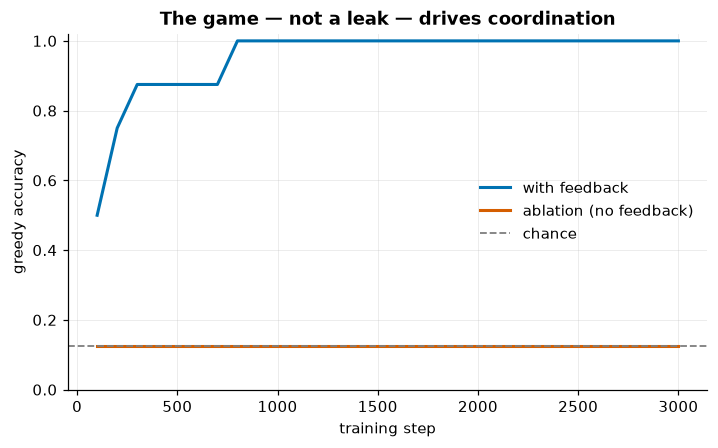

ablation final accuracy = 0.125 (chance 0.125) -> stays at chance: True


In [6]:
cfg_abl = RunConfig(seed=0)
cfg_abl.experiment.num_steps = 3000
cfg_abl.experiment.eval_every = 100
cfg_abl.experiment.feedback = False
steps_a, accs_a, summary_a = run_condition(cfg_abl, "ablation")

fig, ax = plt.subplots()
ax.plot(steps, accs, color=OKABE["blue"], label="with feedback")
ax.plot(steps_a, accs_a, color=OKABE["vermil"], label="ablation (no feedback)")
ax.axhline(chance, color="0.5", ls="--", lw=1.2, label="chance")
ax.set_xlabel("training step"); ax.set_ylabel("greedy accuracy")
ax.set_ylim(0, 1.02); ax.set_title("The game — not a leak — drives coordination")
ax.legend(frameon=False, loc="center right"); plt.show()

print(f"ablation final accuracy = {summary_a['final_accuracy']:.3f} "
      f"(chance {chance:.3f}) -> stays at chance: {summary_a['final_accuracy'] <= 0.30}")

## 3. Turnover — a convention survives its founders

A language that outlives its speakers is meaning-as-public-practice made visible.
We let a convention form, then **freeze the sender** and drop in a **fresh,
randomly initialized receiver** partway through. If the incumbent code is a public
convention (not a private quirk of the original pair), the newcomer re-learns it
and accuracy recovers.

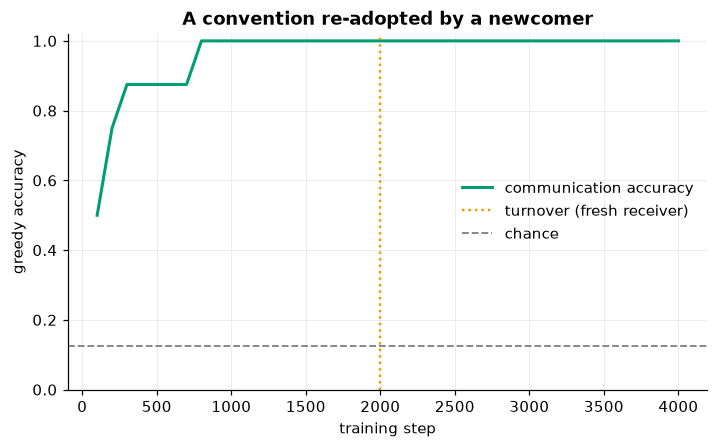

pre-turnover  1.000
post-turnover 1.000  (recovery ratio 1.00)


In [7]:
cfg_to = RunConfig(seed=0)
cfg_to.experiment.num_steps = 4000
cfg_to.experiment.eval_every = 100
cfg_to.experiment.turnover = True
cfg_to.experiment.turnover_at = 0.5
steps_t, accs_t, summary_t = run_condition(cfg_to, "turnover")
turn_step = summary_t["turnover_step"]

fig, ax = plt.subplots()
ax.plot(steps_t, accs_t, color=OKABE["green"], label="communication accuracy")
ax.axvline(turn_step, color=OKABE["orange"], ls=":", lw=1.6,
           label="turnover (fresh receiver)")
ax.axhline(chance, color="0.5", ls="--", lw=1.2, label="chance")
ax.set_xlabel("training step"); ax.set_ylabel("greedy accuracy")
ax.set_ylim(0, 1.02)
ax.set_title("A convention re-adopted by a newcomer")
ax.legend(frameon=False, loc="center right"); plt.show()

eval_events = [{"step": int(s), "accuracy": float(a)} for s, a in zip(steps_t, accs_t)]
fid = metrics.transmission_fidelity(eval_events, turn_step)
print(f"pre-turnover  {fid['pre_turnover_accuracy']:.3f}")
print(f"post-turnover {fid['post_turnover_accuracy']:.3f}  "
      f"(recovery ratio {fid['recovery_ratio']:.2f})")

## 4. Compositional structure — structured referents, structured code

With an *attribute × value* referent grid and a multi-symbol channel (`L>1`), we
can ask whether **similar referents get similar messages** — the signature of a
**compositional** code. We measure it with **topographic similarity**: the
Spearman correlation between pairwise referent distance and pairwise message
distance. (This is only meaningful when referents carry structure, so E1 reports
it only in `grid` mode with `L>1`.)

grid accuracy = 1.000 (chance 0.062)
topographic similarity: rho = 0.634  (p = 8.1e-15)


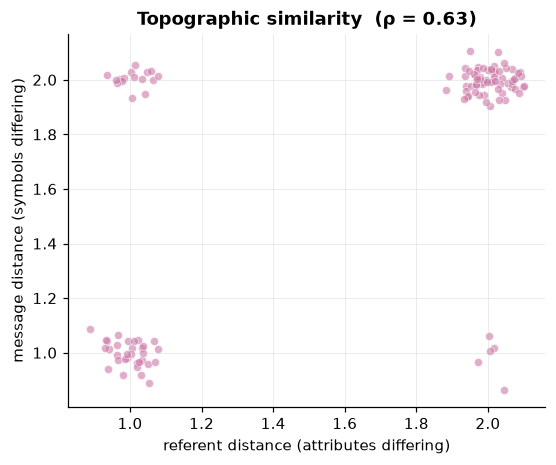

In [8]:
cfg_g = RunConfig(seed=0)
cfg_g.experiment.num_steps = 4000
cfg_g.experiment.eval_every = 200
cfg_g.env.mode = "grid"; cfg_g.env.num_attributes = 2; cfg_g.env.num_values = 4
cfg_g.channel.vocab_size = 6; cfg_g.channel.message_length = 2

tmp = tempfile.mkdtemp(prefix="e1_grid_")
with RunLogger(tmp) as logger:
    summary_g = RunManager(cfg_g, logger=logger).run()

env = SignalingEnv(cfg_g.env); channel = SymbolChannel.from_config(cfg_g.channel)
mapping = summary_g["final_mapping"]
topsim = metrics.topographic_similarity(mapping, env, channel)
print(f"grid accuracy = {summary_g['final_accuracy']:.3f} "
      f"(chance {summary_g['chance']:.3f})")
print(f"topographic similarity: rho = {topsim['rho']:.3f}  (p = {topsim['p_value']:.1e})")

# Scatter: referent distance vs message distance over all referent pairs.
rd, md_ = [], []
K = env.num_classes
for i in range(K):
    for j in range(i + 1, K):
        rd.append(env.referent_distance(i, j))
        md_.append(channel.message_distance(mapping[i], mapping[j]))
rd = np.array(rd) + np.random.default_rng(0).normal(0, 0.05, len(rd))   # jitter
md_ = np.array(md_) + np.random.default_rng(1).normal(0, 0.05, len(md_))

fig, ax = plt.subplots(figsize=(5.6, 4.4))
ax.scatter(rd, md_, s=28, color=OKABE["purple"], alpha=0.6, edgecolor="white", linewidth=0.5)
ax.set_xlabel("referent distance (attributes differing)")
ax.set_ylabel("message distance (symbols differing)")
ax.set_title(f"Topographic similarity  (ρ = {topsim['rho']:.2f})")
plt.show()

A positive correlation means the emergent code is **compositional**: referents
that share attributes tend to share symbols. Structure in the world is mirrored by
structure in the language the agents invented.

## 5. Watching the convention form — the exchange, step by step

The learning curve shows *that* coordination happens; the **transcript** shows
*how*. For each referent we print what the sender says and what the receiver
guesses back — the actual back-and-forth — at several moments in training. Early
on, referents **collide** (two referents get the same symbol) and the receiver
misses; the convention forms as those collisions get resolved into a clean,
agreed mapping. (`beetlebox.analysis.transcript`)

In [9]:
from beetlebox.analysis.transcript import format_convention, format_exchanges

trace_cfg = RunConfig(seed=0)
trace_cfg.experiment.num_steps = 0        # build the agents; we'll train in chunks
mgr = RunManager(trace_cfg)

checkpoints = [0, 100, 300, 800]
step = 0
for target in checkpoints:
    while step < target:
        mgr._train_step(); step += 1
    ev = mgr.evaluate()
    print(format_convention(ev["mapping"], ev["guesses"], step=step, accuracy=ev["accuracy"]))
    print()

convention snapshot @ step 0  (accuracy 0.125)
  referent  sender says   receiver guesses   result
         0           s5                  6   [x]
         1           s5                  6   [x]   <- collides with referent 0
         2           s5                  6   [x]   <- collides with referent 0
         3           s5                  6   [x]   <- collides with referent 0
         4           s5                  6   [x]   <- collides with referent 0
         5           s5                  6   [x]   <- collides with referent 0
         6           s5                  6   [OK]   <- collides with referent 0
         7           s5                  6   [x]   <- collides with referent 0
  1/8 referents correctly communicated

convention snapshot @ step 100  (accuracy 0.500)
  referent  sender says   receiver guesses   result
         0           s0                  7   [x]
         1           s5                  6   [x]
         2           s2                  7   [x]
         3

convention snapshot @ step 300  (accuracy 0.875)
  referent  sender says   receiver guesses   result
         0           s6                  0   [OK]
         1           s4                  1   [OK]
         2           s4                  1   [x]   <- collides with referent 1
         3           s7                  3   [OK]
         4           s1                  4   [OK]
         5           s3                  5   [OK]
         6           s5                  6   [OK]
         7           s2                  7   [OK]
  7/8 referents correctly communicated



convention snapshot @ step 800  (accuracy 1.000)
  referent  sender says   receiver guesses   result
         0           s6                  0   [OK]
         1           s4                  1   [OK]
         2           s0                  2   [OK]
         3           s7                  3   [OK]
         4           s1                  4   [OK]
         5           s3                  5   [OK]
         6           s5                  6   [OK]
         7           s2                  7   [OK]
  8/8 referents correctly communicated



Read top to bottom: at **step 0** every referent gets the same symbol (total
collapse, ~1/8 correct by luck); by **step 100** the sender has begun to
differentiate; at **step 300** typically one stubborn **collision** remains (two
referents still share a symbol — the last coordination problem); by **step 800**
it resolves into a bijection and every referent is communicated. That final
collision snapping apart *is* the shared convention locking in.

We can also watch **individual trials** — the raw "chatter," including the
sender's stochastic exploration (the same referent may draw different symbols
before the policy sharpens):

In [10]:
print("A handful of live trials from the trained agents (stochastic sender):\n")
print(format_exchanges(mgr.sample_exchanges(8, greedy=False)))

A handful of live trials from the trained agents (stochastic sender):

exchange log (individual trials):
  trial   0: referent 4 -> sender says s1 -> receiver guesses 4  [OK]
  trial   1: referent 2 -> sender says s2 -> receiver guesses 7  [x]
  trial   2: referent 4 -> sender says s1 -> receiver guesses 4  [OK]
  trial   3: referent 6 -> sender says s5 -> receiver guesses 6  [OK]
  trial   4: referent 1 -> sender says s4 -> receiver guesses 1  [OK]
  trial   5: referent 3 -> sender says s7 -> receiver guesses 3  [OK]
  trial   6: referent 0 -> sender says s6 -> receiver guesses 0  [OK]
  trial   7: referent 7 -> sender says s2 -> receiver guesses 7  [OK]


> Reconstruct the same transcript from any saved run's event log — no model
> weights needed — with:
> `python -m beetlebox.analysis.transcript results/<config_hash>/seed<seed>`

## What this does (and does not) license

E1 demonstrates the **thin meaning-as-use thesis** and establishes the baseline
that E2–E6 perturb. It says **nothing** about whether the agents "understand"
anything, have inner states, or share a form of life — a stable convention here is
public practice, nothing more (`plan/beetle-box.md` §4.1). The ablation is what
earns the emergence result: coordination sits at chance without a success signal,
so the convention is built from use, not leaked.

See the fully-described [exemplary run](../results/exemplary/e1_signaling/) and the
[approach doc](../docs/e1_signaling.md).